<a href="https://colab.research.google.com/github/dhruvsuri8106-code/ECON-3916---Statistical-and-Machine-Learning/blob/main/Lab%2010%20/%20Lab_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !pip install pandas_datareader
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pandas_datareader import data as pdr
import warnings
warnings.filterwarnings('ignore')

# Define time horizon
start = "2010-01-01"
end = "2024-01-01"

# Fetch a focused set of macro indicators
series = {
    "CPIAUCSL": "cpi",      # Consumer Price Index
    "UNRATE": "unrate",     # Unemployment Rate
    "FEDFUNDS": "fedfunds", # Fed Funds Rate
    "INDPRO": "indpro",     # Industrial Production
    "M2SL": "m2"            # M2 Money Supply
}

# Pull data, normalize to monthly start, and drop NAs
df_list = []
for code, name in series.items():
    s = pdr.DataReader(code, "fred", start, end)
    s.columns = [name]
    df_list.append(s)

df = pd.concat(df_list, axis=1).resample("MS").mean().dropna()
display(df.head())

,cpi,unrate,fedfunds,indpro,m2
DATE,,,,,
2010-01-01,217.488,9.8,0.11,89.3426,8477.7
2010-02-01,217.281,9.8,0.13,89.6779,8527.3
2010-03-01,217.353,9.9,0.16,90.2928,8523.5
2010-04-01,217.403,9.9,0.20,90.5991,8554.8
2010-05-01,217.290,9.6,0.20,91.8230,8609.0


Text(0.5, 1.0, 'The correlation trap(raw levels')

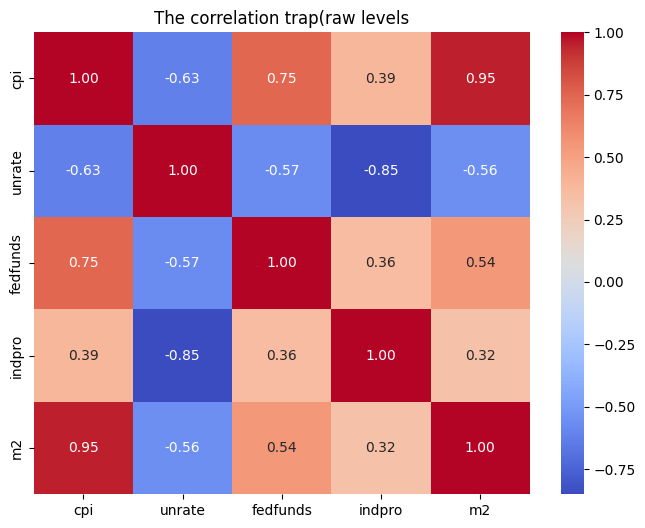

In [2]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm', fmt=".2f")
plt.title('The correlation trap(raw levels')

In [3]:
# Define predictors (X). We leave out CPI as it is our theoretical target.
X = df[['unrate', 'fedfunds', 'indpro', 'm2']]
X = sm.add_constant(X) # Statsmodels requires a constant for VIF

# Calculate VIF iteratively
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]


display(vif_data)

,Feature,VIF
0,const,4252.825829
1,unrate,6.206882
2,fedfunds,1.727582
3,indpro,4.290455
4,m2,1.780273


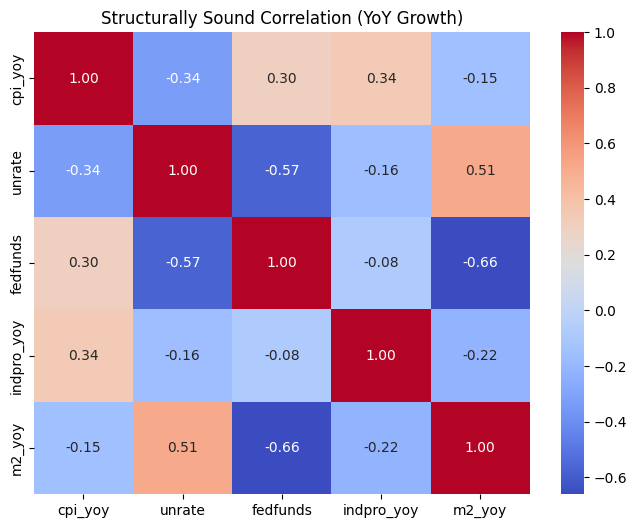

In [4]:
df_t = df.copy()

# Transform trending variables to YoY growth (%)
for col in ["cpi", "indpro", "m2"]:
    df_t[f"{col}_yoy"] = 100 * (df_t[col] / df_t[col].shift(12) - 1)

# Drop missing values created by the 12-month shift
df_t = df_t.dropna()

# Visualize the corrected correlations
cols_to_keep = ['cpi_yoy', 'unrate', 'fedfunds', 'indpro_yoy', 'm2_yoy']
plt.figure(figsize=(8, 6))
sns.heatmap(df_t[cols_to_keep].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Structurally Sound Correlation (YoY Growth)")
plt.show()


In [8]:
import pandas as pd
import plotly.graph_objects as go

# ------------------------------------------------------------
# 1. Exact raw column names from your DataFrame
# ------------------------------------------------------------
raw_cols = ["cpi", "unrate", "fedfunds", "indpro", "m2"]

# Optional: make sure they exist
missing = [col for col in raw_cols if col not in df.columns]
if missing:
    raise KeyError(f"Missing required raw columns: {missing}")

# ------------------------------------------------------------
# 2. Build YoY-transformed variables directly from the raw data
#    This avoids needing pre-existing *_yoy columns.
#
#    YoY % change = ((value_t / value_t-12) - 1) * 100
# ------------------------------------------------------------
df_plot = df.copy()

for col in raw_cols:
    df_plot[f"{col}_yoy"] = df_plot[col].pct_change(12) * 100

yoy_cols = [f"{col}_yoy" for col in raw_cols]

# ------------------------------------------------------------
# 3. Compute correlation matrices
# ------------------------------------------------------------
raw_corr = df_plot[raw_cols].dropna().corr().round(2)
yoy_corr = df_plot[yoy_cols].dropna().corr().round(2)

# Labels shown on the axes
raw_labels = ["CPI", "Unemployment", "Fed Funds", "Industrial Production", "M2"]
yoy_labels = ["CPI YoY", "Unemployment YoY", "Fed Funds YoY", "Industrial Production YoY", "M2 YoY"]

# ------------------------------------------------------------
# 4. Helper function to create readable cell annotations
# ------------------------------------------------------------
def build_annotations(corr_matrix, labels):
    annotations = []
    n = len(labels)

    for i in range(n):
        for j in range(n):
            val = corr_matrix.iloc[i, j]

            # White text on darker cells, black on lighter cells
            text_color = "white" if abs(val) >= 0.5 else "black"

            annotations.append(
                dict(
                    x=labels[j],
                    y=labels[i],
                    text=f"{val:.2f}",
                    showarrow=False,
                    font=dict(color=text_color, size=12)
                )
            )
    return annotations

raw_annotations = build_annotations(raw_corr, raw_labels)
yoy_annotations = build_annotations(yoy_corr, yoy_labels)

# ------------------------------------------------------------
# 5. Create figure with initial RAW correlation heatmap
# ------------------------------------------------------------
fig = go.Figure()

fig.add_trace(
    go.Heatmap(
        z=raw_corr.values,
        x=raw_labels,
        y=raw_labels,
        colorscale="RdBu",
        zmin=-1,
        zmax=1,
        reversescale=True,
        colorbar=dict(title="Correlation"),
        hovertemplate=(
            "Row: %{y}<br>"
            "Column: %{x}<br>"
            "Correlation: %{z:.2f}<extra></extra>"
        )
    )
)

# ------------------------------------------------------------
# 6. Add dropdown menu to switch between Raw and YoY views
# ------------------------------------------------------------
fig.update_layout(
    title="Macroeconomic Correlation Dashboard",
    width=900,
    height=750,
    template="plotly_white",
    xaxis=dict(side="bottom"),
    yaxis=dict(autorange="reversed"),
    annotations=raw_annotations,
    updatemenus=[
        dict(
            type="dropdown",
            direction="down",
            x=0.02,
            y=1.12,
            xanchor="left",
            yanchor="top",
            showactive=True,
            buttons=[
                dict(
                    label="Raw Variables",
                    method="update",
                    args=[
                        {
                            "z": [raw_corr.values],
                            "x": [raw_labels],
                            "y": [raw_labels]
                        },
                        {
                            "title": "Correlation Matrix: Raw Variables",
                            "annotations": raw_annotations
                        }
                    ]
                ),
                dict(
                    label="YoY Variables",
                    method="update",
                    args=[
                        {
                            "z": [yoy_corr.values],
                            "x": [yoy_labels],
                            "y": [yoy_labels]
                        },
                        {
                            "title": "Correlation Matrix: YoY Variables",
                            "annotations": yoy_annotations
                        }
                    ]
                )
            ]
        )
    ],
    margin=dict(t=120, l=100, r=40, b=60)
)

fig.show()